# HOMEWORK 9

In this homework, you are going to use the dlib face detector and apply it to an image of your liking. You can follow the procedure shown in lesson 9. Please always comment your code so I can see what you're doing :-)

For this homework we are not going to provide you with any code, you'll have to build the face detector on your own.

### Step 0

Run the necessary imports.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

### Step 1

Load an image (any image that contains faces).

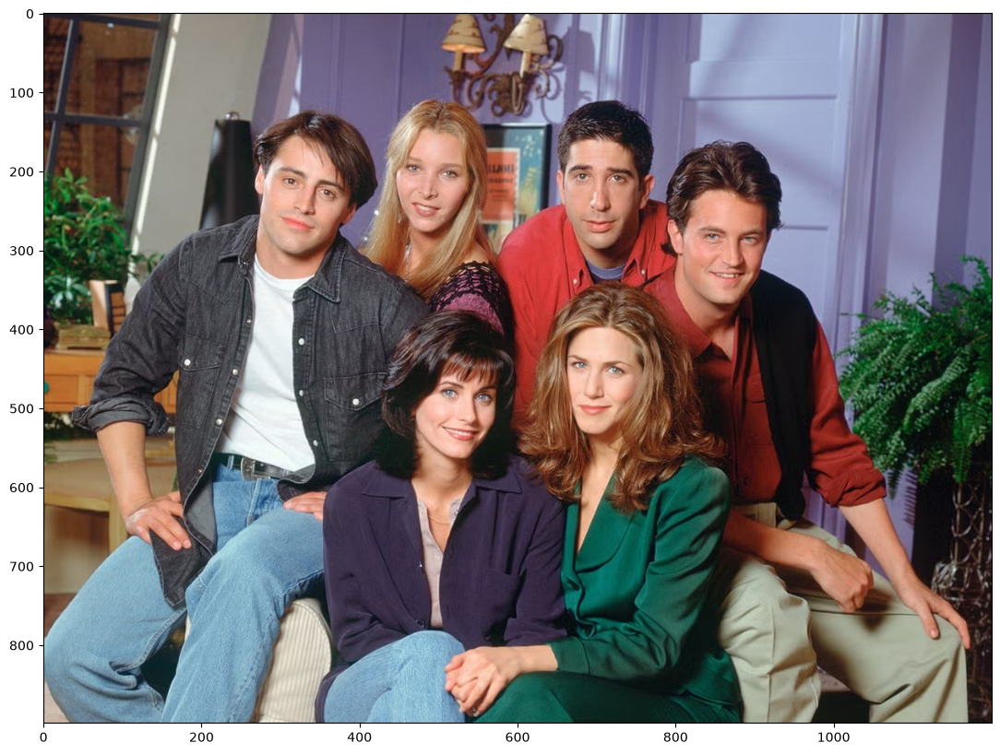

In [10]:
img = cv2.imread("../data/friends.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

### Step 2

Load the dlib face detector.

In [2]:
import dlib

#get the dlib frontal face detector
detector = dlib.get_frontal_face_detector()

### Step 3

Run the detector on your image.

In [13]:
#prepare image. dlib face detector works with gray scale representation
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
#find faces using dlib face detector (here 2nd parameter forces the detector to
#enlarge image before face detection. This helps with smaller faces)
#Be carefull - the larger 2nd parameter the more resources needed
faces = detector(gray, 1)

### Step 4

Draw bounding boxes around the detected faces and plot the image. Use different colour for each face.

6  faces on the image  42.5


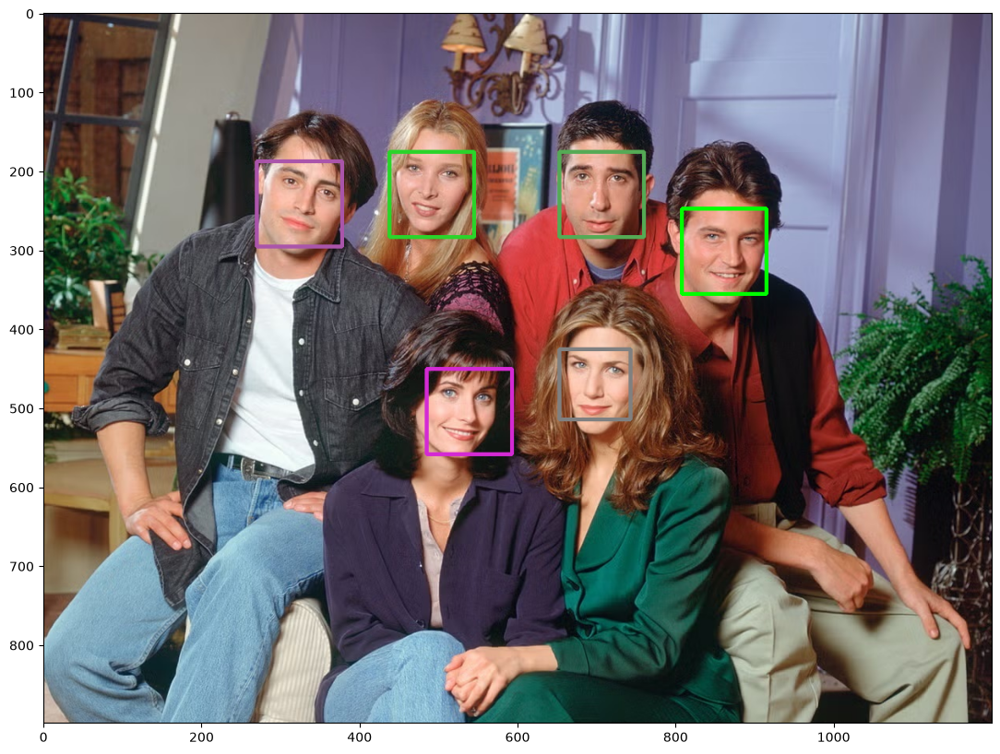

In [14]:
#count the found boxes
face_count = len(faces)
#calculate the colors change according to faces count
box_color_increment = 255 / face_count
#initialize color increment
box_color = 0

#get coordinates of face boxes
for face in faces:
    x0 = face.left()
    y0 = face.top()
    x1 = face.right()
    y1 = face.bottom()

    #draw the found face rectangles on the image using different box colors
    cv2.rectangle(img, (x0, y0), (x1, y1), (0 + box_color, 255 - box_color, 0 + box_color), 3)
    #change color
    box_color += box_color_increment

print(face_count, " faces on the image ", box_color_increment)
plt.imshow(img)

### Step 5 (optional)

Repeat the process with a different and more challenging image (more faces, smaller faces, people with glasses, hats, helmets, etc.). How does the detector perform? Is it robust?

3  faces on the image 


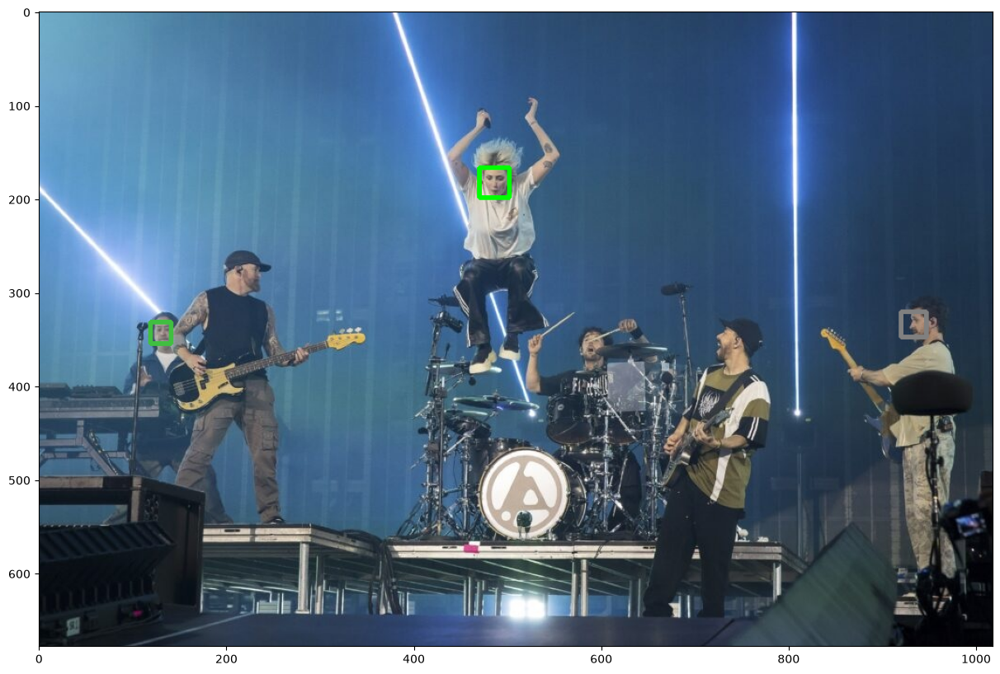

In [3]:
#get the dlib frontal face detector
detector = dlib.get_frontal_face_detector()

def find_face(img, det, depth):
    #prepare image. dlib face detector works with gray scale representation
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    #find faces using dlib face detector (here 2nd parameter forces the detector to
    #enlarge image before face detection. This helps with smaller faces)
    faces = det(gray, depth)

    #count the found boxes
    face_count = len(faces)
    #calculate the colors change according to faces count
    box_color_increment = 255 / (face_count + 1)
    #initialize color increment
    box_color = 0

    #get coordinates of face boxes
    for face in faces:
        x0 = face.left()
        y0 = face.top()
        x1 = face.right()
        y1 = face.bottom()

        #draw the found face rectangles on the image using different box colors
        cv2.rectangle(img, (x0, y0), (x1, y1), (0 + box_color, 255 - box_color, 0 + box_color), 3)
        #change the color
        box_color += box_color_increment

    print(face_count, " faces on the image ")
    #return result
    return img

img1 = cv2.imread("../data/linkin_park.jpg")
img1 = find_face(img1, detector, 3)
plt.imshow(img1)

2  faces on the image 


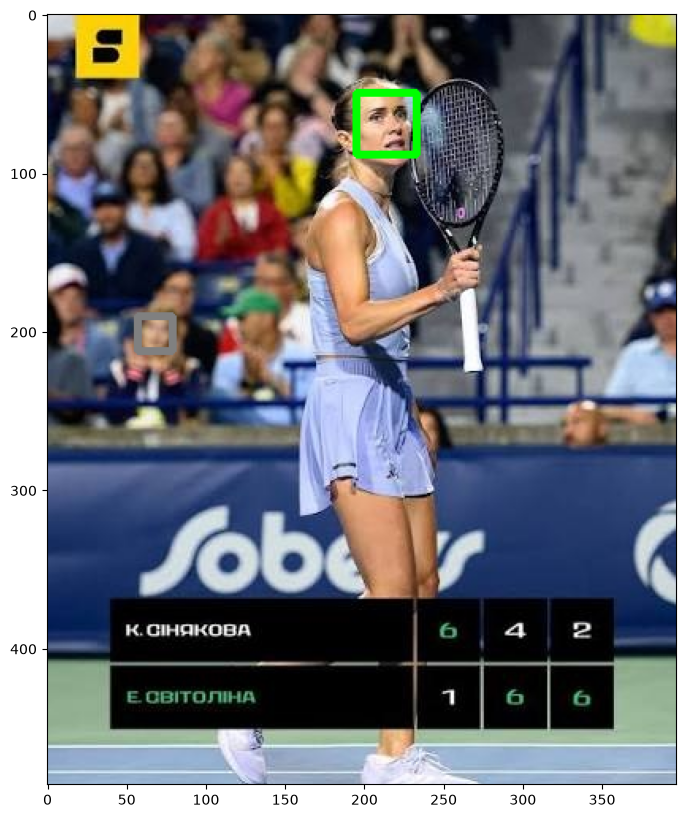

In [16]:
img2 = cv2.imread("../data/svitolina.jpg")
img2 = find_face(img2, detector, 3)
plt.imshow(img2)

4  faces on the image 


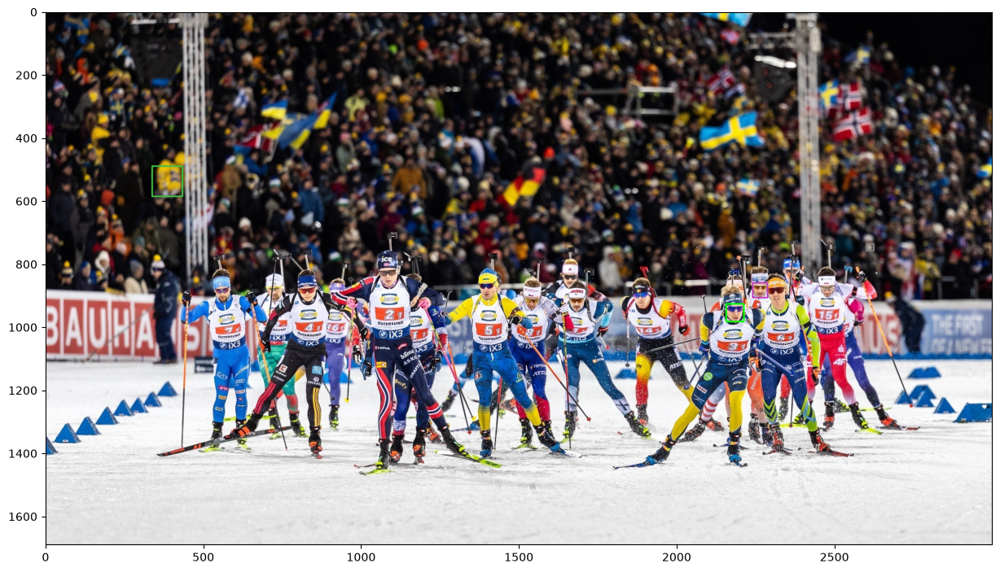

In [17]:
img3 = cv2.imread("../data/biathlon.jpg")
img3 = find_face(img3, detector, 3)
plt.imshow(img3)

3  faces on the image 


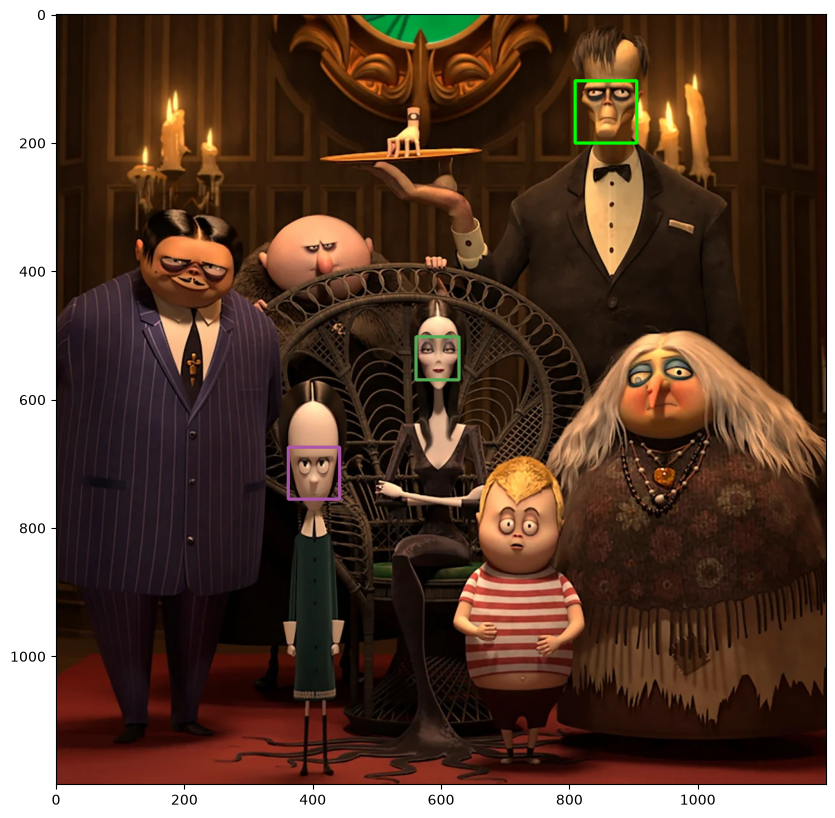

In [18]:
img4 = cv2.imread("../data/adams_family.jpg")
img4 = find_face(img4, detector, 3)
plt.imshow(img4)

In [ ]:
#As far as I can see this face detector works surprisingly good. It managed
#to find side face on the likin_park.jpg (however only one of three side faces),
#it also found very tiny and blury face in svitolina.jpg. The problems started
#with biathlon.jpg where it lost to find all faces with glasses and found NOT FACES.
#Futhermore it failed with cartoons faces in adams_family.jpg (possible reason - too
#unreal propotions). The documentation says that this method works well with face sizes more
#than 80x80 pixels which can explain a lot

0  faces on the image 


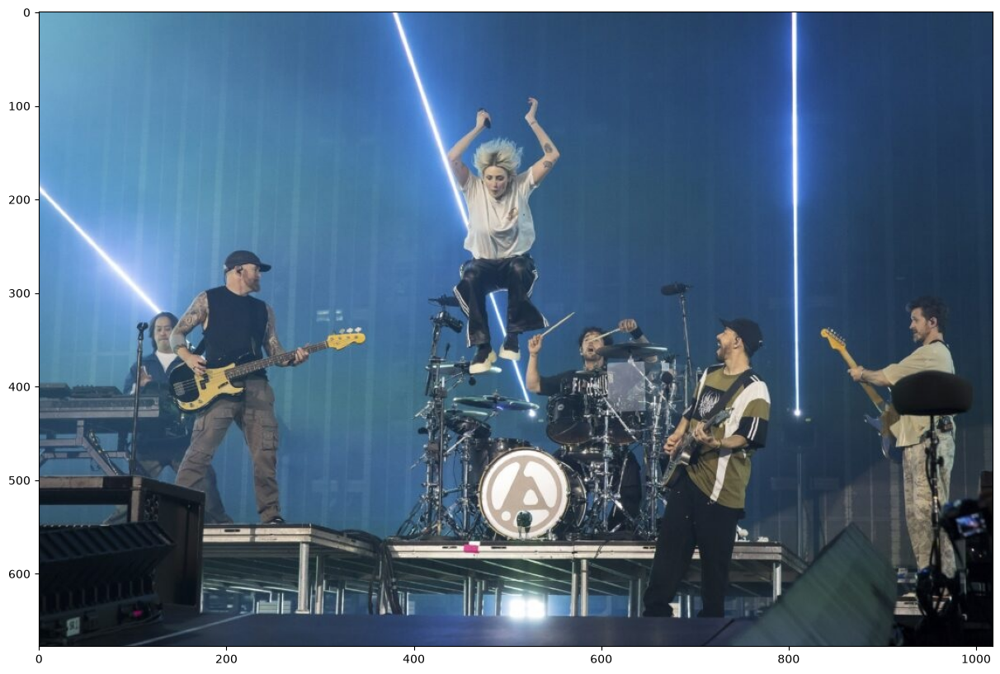

In [7]:
#so lets try another dlib detector
def find_face(img, det, depth):
    #prepare image. dlib face detector works with gray scale representation
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    #find faces using dlib face detector (here 2nd parameter forces the detector to
    #enlarge image before face detection. This helps with smaller faces)
    faces = det(gray, depth)

    #count the found boxes
    face_count = len(faces)
    #calculate the colors change according to faces count
    box_color_increment = 255 / (face_count + 1)
    #initialize color increment
    box_color = 0

    #get coordinates of face boxes
    for face in faces:
        x0 = face.rect.left()
        y0 = face.rect.top()
        x1 = face.rect.right()
        y1 = face.rect.bottom()

        #draw the found face rectangles on the image using different box colors
        cv2.rectangle(img, (x0, y0), (x1, y1), (0 + box_color, 255 - box_color, 0 + box_color), 3)
        #change the color
        box_color += box_color_increment

    print(face_count, " faces on the image ")
    #return result
    return img


detector_2 = dlib.cnn_face_detection_model_v1("../data/mmod_human_face_detector.dat")
img1 = cv2.imread("../data/linkin_park.jpg")
img1 = find_face(img1, detector_2, 0)
plt.imshow(img1)

0  faces on the image 


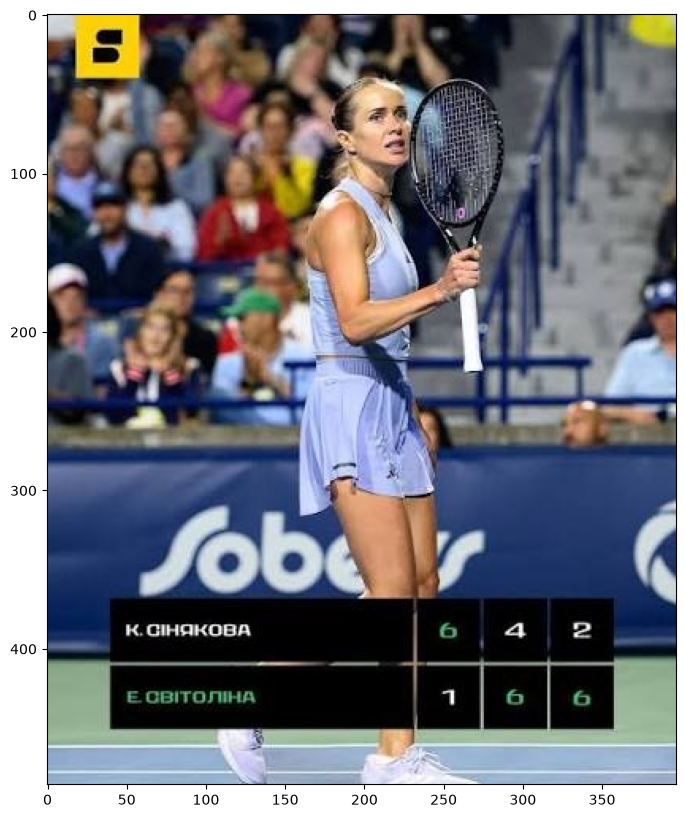

In [25]:
img2 = cv2.imread("../data/svitolina.jpg")
img2 = find_face(img2, detector_2, 0)
plt.imshow(img2)

5  faces on the image 


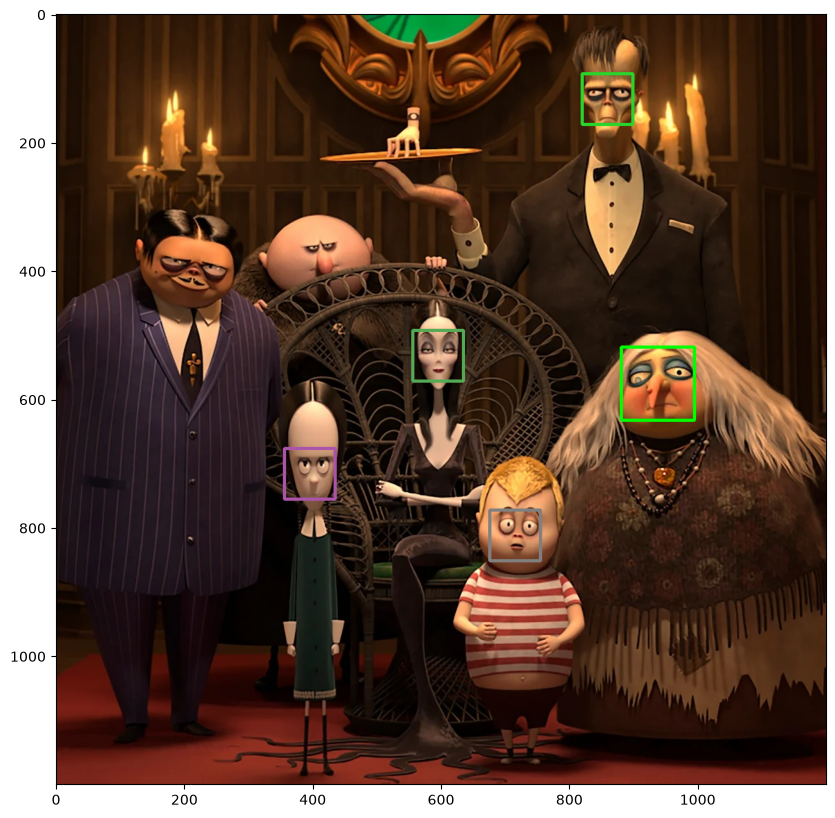

In [8]:
img4 = cv2.imread("../data/adams_family.jpg")
img4 = find_face(img4, detector_2, 0)
plt.imshow(img4)

In [ ]:
#I am surprised with the results, because the dlib promised to cope
#better with tilted and occluded faces. It also promised to be resources
#cheep but I did not manage to run biathlon.com (it is realy large image).
#Who needs to track animated characters or have I done something wrong?